# Descriptive analysis of the ACR appropriateness criteria for abdominal/pelvic emergency department presentations

Efforts to improve CT use have focused on evidence-based decision rules and clinical practice guidelines. Among these, the American College of Radiology (ACR) Appropriateness Criteria (AC) characterize imaging modalities as usually appropriate, may be appropriate, or usually not appropriate. We determined the frequency of CT and alternative imaging ratings in ACR AC for adult patients with abdominal complaints.

## Data import and initial filtering

During October and November, 2024, a [web-scraping process](scrape.py) was used to download the structured imaging appropriateness ratings of the AC from the [ACR AC Portal](https://gravitas.acr.org/acportal) using links provided to each scenario on the portal home page. These links are stored in [acr_ac_scenarios.csv](acr_ac_scenarios.csv) (accessed Oct 2024). Final study appropriateness for each scenario is stored in [combined.csv](combined.csv)

Data was accessed in accordance with the [ACR website terms and conditions]("ACR AC Terms and Conditions-20250103.txt") and the [ACR website robots.txt file](acr-2025-0103-robots.txt). 

In [1]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
scenarios = pd.read_csv('acr_ac_scenarios.csv')
print(f"{len(scenarios)} scenarios loaded.")
scenarios.head()

3346 scenarios loaded.


,panel,scenario-id,scenario-text,scenario-url,sex,age,body-area,priority-clinical-areas
0,Breast,3110141,"Axillary adenopathy, breast cancer suspected",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=3209,Male Only,18 - 150,Breast,NaN
1,Breast,3194817,"Axillary lump, palpable, new, bilateral, initial axilla imaging",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5930,Female Only,18 - 150,Breast,NaN
2,Breast,3194815,"Axillary lump, palpable, new, unilateral, initial axilla imaging",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5929,Female Only,18 - 150,Breast,NaN
3,Breast,3194837,"Axillary node, suspicious on imaging, not mammo or US, next imaging study",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5940,Female Only,18 - 150,Breast,NaN
4,Breast,3194835,"Axillary node, suspicious on mammo or US, next imaging study",https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=5939,Female Only,18 - 150,Breast,NaN


### Filter criteria

Scenarios are filtered to abdominal and pelvic complaints that are applicable to Emergency Department presentations, with exclusions. 

- Limit first by body area as defined in the ACR AC metadata.
- Exclude scenarios applicable to pediatrics, as the imaging decisions in these patients is significantly different than the adult population
- Exclude scenarios applicable to pregnant patients for the same reason.
- Remove scenarios related to interventional radiology
- Exclude scenarios related to cancer screening, staging, or pre-operative planning as these are not applicable to the emergency department.
- Added back scenarios removed above based on expert review as applicable to the ED. (1 of 2 recommends)
- Removed included scenarios based on expert review as applicable to the ED. (2 of 2 recommend) 
- Duplicates removed 

In [2]:
scenarios['body-area'].unique()

<StringArray>
[              'Breast',        'Cardiac-chest', 'Chest-abdomen-pelvis',
        'Chest-abdomen',              'Cardiac',                'Chest',
 'cardiac-chest-pelvis',       'Abdomen-pelvis',              'Abdomen',
               'Pelvis',           'Neck-chest',          'Unspecified',
          'Extremities',                'Spine',      'Lower extremity',
      'Upper extremity',         'Spine-pelvis',                 'Head',
                 'Neck',            'Head-neck',              'Maxface',
           'Head-spine']
Length: 22, dtype: str

In [3]:
filtered_scenarios = scenarios[scenarios['body-area'].isin(['Chest-abdomen', 'Chest-abdomen-pelvis', 'Abdomen-pelvis', 'Abdomen', 'Pelvis'])]
body_area_n = len(filtered_scenarios)
print(f"Number of filtered scenarios by body area: {body_area_n}")

filtered_scenarios = filtered_scenarios[filtered_scenarios['panel'] != 'Pediatric']
without_peds_n = len(filtered_scenarios)
print(f"Number of filtered scenarios without pediatric: {without_peds_n}")

filtered_scenarios = filtered_scenarios[~filtered_scenarios['scenario-text'].str.contains('pregnant', case=False, na=False)]
without_pregnant_n = len(filtered_scenarios)
print(f"Number of filtered scenarios without pregnant: {without_pregnant_n}")

filtered_scenarios = filtered_scenarios[filtered_scenarios['panel'] != 'Interventional Radiology']
without_IR_n = len(filtered_scenarios)
print(f"Number of filtered scenarios without interventional radiology: {without_IR_n}")

pattern_list = ['staging', 
                'screen', 
                'surveillance',
                'incidental finding',
                'imaging during treatment',
                'posttreatment imaging',
                'post treatment imaging',
                'preop planning',
                'pre-op planning'
                ]

pattern = '|'.join(pattern_list)
filtered_scenarios = filtered_scenarios[~filtered_scenarios['scenario-text'].str.contains(pattern, case=False, na=False)]
without_monitoring_n = len(filtered_scenarios)
print(f"Number of filtered scenarios without monitoring: {without_monitoring_n}")


Number of filtered scenarios by body area: 620
Number of filtered scenarios without pediatric: 562
Number of filtered scenarios without pregnant: 547
Number of filtered scenarios without interventional radiology: 509
Number of filtered scenarios without monitoring: 398


### Expert review

The list of scenarios selected by the above filters, as well as the excluded scenarios, were reviewed by two ABEM board-certified emergency physicians (JB and KK) for validity. 

An inclusive approach for alteration of the lists was used:
1. If either reviewer felt an excluded scenario was appropriate for the study question (abdominal or pelvic complaints presenting to the emergency department), then the selected scenario was added back to the study group.
2. If both reviewers felt an included scenario was excluded, then the scenario was removed from the study group.

In [4]:
specific_scenarios_to_include = pd.read_csv('include.csv')
specific_scenarios_to_exclude = pd.read_csv('exclude.csv')

# Display included scenarios
included_scenarios = scenarios[
    scenarios['scenario-id'].isin(specific_scenarios_to_include['scenario-id'].drop_duplicates())
    ].drop_duplicates(subset=['scenario-id'])
print(f"{len(included_scenarios)} scenarios added back:")
display(included_scenarios[['scenario-id', 'scenario-text']])

# Add included scenarios back to the filtered scenarios
filtered_scenarios = pd.concat([filtered_scenarios, included_scenarios])
print(f"Number of filtered scenarios after adding back included scenarios: {len(filtered_scenarios)}\n")

# Display excluded scenarios
excluded_scenarios = scenarios[
    scenarios['scenario-id'].isin(specific_scenarios_to_exclude['scenario-id'])
    ].drop_duplicates(subset=['scenario-id'])
print(f"{len(excluded_scenarios)} scenarios removed:")
display(excluded_scenarios[['scenario-id', 'scenario-text']])

# Remove excluded scenarios from the filtered scenarios
filtered_scenarios = filtered_scenarios[~filtered_scenarios['scenario-id'].isin(specific_scenarios_to_exclude['scenario-id'])]
print(f"Number of filtered scenarios after removing excluded scenarios: {len(filtered_scenarios)}\n")


19 scenarios added back:


,scenario-id,scenario-text
308,3102641,"Liver disease, chronic, fibrosis suspected, diagnosis and staging, initial imaging"
365,3196683,"Sepsis suspected, non specific symptoms, unknown origin, chest radiography equivocal, next imaging study"
366,3196684,"Sepsis suspected, non specific symptoms, unknown origin, chest radiography nonspecific, next imaging study"
367,3196682,"Sepsis suspected, non specific symptoms, unknown origin, chest radiography normal, next imaging study"
369,3196689,"Sepsis suspected, cannot assess symptoms, chest radiography equivocal, next imaging study"
370,3196690,"Sepsis suspected, cannot assess symptoms, chest radiography nonspecific, next imaging study"
371,3196688,"Sepsis suspected, cannot assess symptoms, chest radiography normal, next imaging study"
372,3196679,"Sepsis suspected, cannot assess symptoms, initial imaging"
385,3196677,"Sepsis suspected, non specific symptoms, unknown origin, initial imaging"
387,3196691,"Sepsis, cannot assess symptoms, chest radiography normal, next imaging study"


Number of filtered scenarios after adding back included scenarios: 417

173 scenarios removed:


,scenario-id,scenario-text
331,3164902,"Pancreas cyst, <=2.5cm, incidental, initial evaluation"
332,3164904,"Pancreas cyst, >2.5cm, incidental, high risk features, initial evaluation"
333,3164903,"Pancreas cyst, >2.5cm, incidental, no high risk features, initial evaluation"
334,3164906,"Pancreas cyst, follow-up imaging"
335,3164905,"Pancreas duct dilation, >7mm, IPMN suspected, initial evaluation"
336,3128539,"Pancreatic adenocarcinoma, post neoadjuvant tx, eval for resectability"
416,3197148,"Adnexal mass suspected, no acute symptoms, postmenopausal, initial imaging"
418,3074166,"Adnexal mass suspected, no acute symptoms, premenopausal, initial imaging"
419,3082200,"Adnexal mass, likely benign, no acute symptoms, postmenopausal, follow-up imaging"
420,3074171,"Adnexal mass, likely benign, no acute symptoms, premenopausal, follow-up imaging"


Number of filtered scenarios after removing excluded scenarios: 244



### Remove duplicates

Some scenarios are duplicated in the base ACR dataset - this happens primarily when a single scenario applies to multiple 'panels'. It was separately demonstrated that all duplicate scenarios (based on scenario-text) contain the same imaging study recommendations, so here we simply drop duplicates from the filtered set of scenarios.

In [5]:
duplicates_dropped = filtered_scenarios[filtered_scenarios.duplicated(subset=['scenario-text'], keep='first')][['scenario-id', 'scenario-text']]
filtered_scenarios = filtered_scenarios.drop_duplicates(subset=['scenario-text'], keep='first')

print(f"{len(duplicates_dropped)} duplicate scenarios dropped")
print(f"Number of unique scenarios after dropping duplicates: {len(filtered_scenarios)}")

21 duplicate scenarios dropped
Number of unique scenarios after dropping duplicates: 223


## Categorization of ACR appropriateness ratings

For each scenario in the filtered dataset, load all of the associated studies and their appropriateness ratings from the ACR. Flags are set for each scenario to indicate appropriateness of each of the following categories:
- CT (any CT study type, e.g. CT with contrast, CT without contrast, CTA)
- Other (any study that is not CT)
- MR (any MR study type)
- US (any US study type)
- Other modalities (any study that is not CT, MR, or US. e.g. plain radiography)

In [6]:
# Load all studies with appropriateness ratings from the downloaded ACR dataset

studies = pd.read_csv('data/combined.csv')
display(studies['appropriateness'].unique())
display(studies['procedure'].unique())

<StringArray>
[              'Usually appropriate',                'May be appropriate',
 'May be appropriate (Disagreement)',           'Usually not appropriate']
Length: 4, dtype: str

<StringArray>
[                             'MRA chest without and with IV contrast',
                                       'MRA chest without IV contrast',
      'MRI heart function and morphology without and with IV contrast',
               'MRI heart function and morphology without IV contrast',
                              'CTA coronary arteries with IV contrast',
                        'Arteriography coronary with ventriculography',
                            'MRA abdomen without and with IV contrast',
         'MRI heart function with stress without and with IV contrast',
                  'MRI heart function with stress without IV contrast',
                                          'CTA chest with IV contrast',
 ...
                                     'US pregnant uterus transvaginal',
                                              'US assessment for TTTS',
                                   'US duplex Doppler pregnant uterus',
                                            '

In [7]:
for index, scenario in filtered_scenarios.iterrows():
    # Get all studies for this scenario
    scenario_studies = studies[studies['scenario-id'] == scenario['scenario-id']]
    
    # Check if any CT procedures are usually appropriate
    ct_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually appropriate')
    ]
    filtered_scenarios.at[index, 'ct_usually_appropriate'] = len(ct_studies) > 0
    
    # Check if any CT procedures are 'may be appropriate'
    ct_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'].str.startswith('May be appropriate', na=False))
    ]
    filtered_scenarios.at[index, 'ct_may_be_appropriate'] = len(ct_studies) > 0

    # Check if any CT procedures are NOT appropriate
    ct_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually not appropriate')
    ]
    filtered_scenarios.at[index, 'ct_not_appropriate'] = len(ct_studies) > 0
    
    # Are non CT studies usually appropriate?
    non_ct_studies = scenario_studies[
        (~scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually appropriate')
    ]
    filtered_scenarios.at[index, 'other_usually_appropriate'] = len(non_ct_studies) > 0

    # Are non CT studies 'may be appropriate'?
    non_ct_studies = scenario_studies[
        (~scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'].str.startswith('May be appropriate', na=False))
    ]
    filtered_scenarios.at[index, 'other_may_be_appropriate'] = len(non_ct_studies) > 0

    # Are non CT studies NOT appropriate?
    non_ct_studies = scenario_studies[
        (~scenario_studies['procedure'].str.startswith('CT', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually not appropriate')
    ]
    filtered_scenarios.at[index, 'other_not_appropriate'] = len(non_ct_studies) > 0

    # Check if any MR procedures are usually appropriate
    mr_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('MR', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually appropriate')
    ]
    filtered_scenarios.at[index, 'mr_usually_appropriate'] = len(mr_studies) > 0
    
    # Check if any MR procedures are may be appropriate
    mr_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('MR', na=False)) & 
        (scenario_studies['appropriateness'].str.startswith('May be appropriate', na=False))
    ]
    filtered_scenarios.at[index, 'mr_may_be_appropriate'] = len(mr_studies) > 0

    # Check if any MR procedures are NOT appropriate
    mr_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('MR', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually not appropriate')
    ]
    filtered_scenarios.at[index, 'mr_not_appropriate'] = len(mr_studies) > 0

    # Check if any US procedures are usually appropriate
    us_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('US', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually appropriate')
    ]
    filtered_scenarios.at[index, 'us_usually_appropriate'] = len(us_studies) > 0
    
    # Check if any US procedures are may be appropriate
    us_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('US', na=False)) & 
        (scenario_studies['appropriateness'].str.startswith('May be appropriate', na=False))
    ]
    filtered_scenarios.at[index, 'us_may_be_appropriate'] = len(us_studies) > 0

    # Check if any US procedures are NOT appropriate
    us_studies = scenario_studies[
        (scenario_studies['procedure'].str.startswith('US', na=False)) & 
        (scenario_studies['appropriateness'] == 'Usually not appropriate')
    ]
    filtered_scenarios.at[index, 'us_not_appropriate'] = len(us_studies) > 0
    
    # Classify non-CT/MR/US studies

    other_modality_studies = scenario_studies[
        (~scenario_studies['procedure'].str.startswith('CT', na=False)) &
        (~scenario_studies['procedure'].str.startswith('MR', na=False)) &
        (~scenario_studies['procedure'].str.startswith('US', na=False))
    ]
    filtered_scenarios.at[index, 'other_modality_usually_appropriate'] = len(
        other_modality_studies[other_modality_studies['appropriateness'] == 'Usually appropriate']
    ) > 0
    filtered_scenarios.at[index, 'other_modality_may_be_appropriate'] = len(
        other_modality_studies[other_modality_studies['appropriateness'].str.startswith('May be appropriate', na=False)]
    ) > 0
    filtered_scenarios.at[index, 'other_modality_not_appropriate'] = len(
        other_modality_studies[other_modality_studies['appropriateness'] == 'Usually not appropriate']
    ) > 0

## Descriptive statistics

How often is CT usually appropriate for ED abdominal complaints?

In [8]:
def ct_usually_appropriate(data):
    n_usually_appropriate = data['ct_usually_appropriate'].sum()
    percentage_usually_appropriate = (n_usually_appropriate / len(data)) * 100

    print(f"Number of scenarios where a CT study is usually appropriate: {n_usually_appropriate}")
    print(f"Percentage of scenarios where a CT study is usually appropriate: {percentage_usually_appropriate:.2f}%")

ct_usually_appropriate(filtered_scenarios)

Number of scenarios where a CT study is usually appropriate: 162
Percentage of scenarios where a CT study is usually appropriate: 72.65%


How often is CT the ONLY usually appropriate study?

In [9]:
def ct_only_usually_appropriate(data):
    ct_only_appropriate = data[(data['ct_usually_appropriate'] == True) & (data['other_usually_appropriate'] == False)]
    num_ct_only = len(ct_only_appropriate)
    pct_ct_only = (num_ct_only / len(data)) * 100

    print(f"Number of cases where only CT is usually appropriate: {num_ct_only}")
    print(f"Percentage of cases where only CT is usually appropriate: {pct_ct_only:.1f}%")

    display(ct_only_appropriate[['scenario-text']])

ct_only_usually_appropriate(filtered_scenarios)

Number of cases where only CT is usually appropriate: 48
Percentage of cases where only CT is usually appropriate: 21.5%


,scenario-text
246,"Abd pain, acute, nonlocalized, fever, initial exam"
247,"Abd pain, acute, nonlocalized, fever, post op, initial exam"
249,"Abd pain, acute, nonlocalized, neutropenic, initial exam"
265,"Abscess, liver"
281,"Diaphragmatic hernia suspected, Bochdalek, initial imaging"
282,"Diaphragmatic hernia suspected, Morgagni, initial imaging"
283,"Diaphragmatic hernia suspected, traumatic, initial imaging"
326,"LLQ pain, diverticulitis complications suspected, initial imaging"
327,"LLQ pain, diverticulitis suspected, initial imaging"
328,"LLQ pain, initial imaging"


How often is CT 'usually appropriate' or 'may be appropriate'?

In [10]:
def ct_usually_or_may_be_appropriate(data):
    appropriate_percentage = ((data['ct_usually_appropriate'] | data['ct_may_be_appropriate']).mean() * 100)
    n_usually_or_may_be_appropriate = ((data['ct_usually_appropriate'] | data['ct_may_be_appropriate']).sum())

    print(f"Percentage of cases where CT is 'usually' or 'may be' appropriate: {appropriate_percentage:.1f}% (n={n_usually_or_may_be_appropriate})")

ct_usually_or_may_be_appropriate(filtered_scenarios)

Percentage of cases where CT is 'usually' or 'may be' appropriate: 87.4% (n=195)


When is it NOT appropriate to use a CT study?

In [11]:
def ct_not_appropriate(data):
    ct_not_appropriate_studies = data[(data['ct_usually_appropriate'] == False) & 
            (data['ct_may_be_appropriate'] == False) &
            (data['ct_not_appropriate'] == True)]

    n_ct_not_appropriate = len(ct_not_appropriate_studies)
    percentage_ct_not_appropriate = (n_ct_not_appropriate / len(data)) * 100

    print(f"Percentage of cases where CT is only not appropriate: {percentage_ct_not_appropriate:.1f}% (n={n_ct_not_appropriate})\n")
    display(ct_not_appropriate_studies['scenario-text'])

ct_not_appropriate(filtered_scenarios)


Percentage of cases where CT is only not appropriate: 12.1% (n=27)



295                                                                Epigastric pain, hiatal hernia suspected, initial imaging
450                                                                                 Endometriosis suspected, initial imaging
451                                                                   Endometriosis suspected, rectosigmoid, initial imaging
452                                          Endometriosis suspected, US indeterminate, next imaging study, characterization
453                                        Endometriosis suspected, US indeterminate, next imaging study, treatment planning
454                                               Endometriosis suspected, US negative, next imaging study, characterization
455                                             Endometriosis suspected, US negative, next imaging study, treatment planning
456                                                  Endometriosis, postoperative diagnosis, new symptoms, follow-up imaging


When is no imaging at all recommended?

In [12]:
def no_studies_recommended(data):
    no_studies_recommended = data[(data['ct_usually_appropriate'] == False) & 
                                  (data['ct_may_be_appropriate'] == False) & 
                                  (data['other_usually_appropriate'] == False) & 
                                  (data['other_may_be_appropriate'] == False)]

    print(f"Percentage of cases where no studies are recommended: {len(no_studies_recommended) / len(data) * 100:.1f}% (n={len(no_studies_recommended)})\n")
    display(no_studies_recommended['scenario-text'])

no_studies_recommended(filtered_scenarios)

Percentage of cases where no studies are recommended: 0.9% (n=2)



3106    Pyelonephritis suspected, acute, uncomplicated, first time presentation, initial imaging
3184                         UTI, lower urinary tract, recurrent, uncomplicated, no risk factors
Name: scenario-text, dtype: str

## Second level analysis - CT vs all other modalities

If we compare those scenarios where CT is "usually", "may be", or "usually not" appropriate to the same classification for all other modalities, we can classify all scenarios into a 9x9 grid as follows:

![9x9 analysis grid](supplemental/analysis_grid.png)


In [13]:
# green-green: True only if CT and alternative are usually appropriate

filtered_scenarios['green-green'] = (filtered_scenarios['ct_usually_appropriate'] == True) & \
                            (filtered_scenarios['other_usually_appropriate'] == True)

# green-yellow: True if CT is usually appropriate but alternative is only maybe appropriate

filtered_scenarios['green-yellow'] = (filtered_scenarios['ct_usually_appropriate'] == True) & \
                                    (filtered_scenarios['other_usually_appropriate'] == False) & \
                                    (filtered_scenarios['other_may_be_appropriate'] == True)

# green-red: True if CT is usually appropriate but alternative is not appropriate

filtered_scenarios['green-red'] = (filtered_scenarios['ct_usually_appropriate'] == True) & \
                            (filtered_scenarios['other_usually_appropriate'] == False) & \
                            (filtered_scenarios['other_may_be_appropriate'] == False) & \
                            (filtered_scenarios['other_not_appropriate'] == True)

# yellow-green: True if CT is maybe appropriate but alternative is usually appropriate

filtered_scenarios['yellow-green'] = (filtered_scenarios['ct_usually_appropriate'] == False) & \
                                     (filtered_scenarios['ct_may_be_appropriate'] == True) & \
                                     (filtered_scenarios['other_usually_appropriate'] == True)

# yellow-yellow: True if CT and alternative are maybe appropriate

filtered_scenarios['yellow-yellow'] = (filtered_scenarios['ct_usually_appropriate'] == False) & \
                             (filtered_scenarios['ct_may_be_appropriate'] == True) & \
                             (filtered_scenarios['other_usually_appropriate'] == False) & \
                             (filtered_scenarios['other_may_be_appropriate'] == True)

# yellow-red: True if CT is maybe appropriate but alternative is not appropriate

filtered_scenarios['yellow-red'] = (filtered_scenarios['ct_usually_appropriate'] == False) & \
                            (filtered_scenarios['ct_may_be_appropriate'] == True) & \
                            (filtered_scenarios['other_usually_appropriate'] == False) & \
                            (filtered_scenarios['other_may_be_appropriate'] == False) & \
                            (filtered_scenarios['other_not_appropriate'] == True)

# red-green: True if CT is not appropriate but alternative is usually appropriate

filtered_scenarios['red-green'] = (filtered_scenarios['ct_usually_appropriate'] == False) & \
                            (filtered_scenarios['ct_may_be_appropriate'] == False) & \
                            (filtered_scenarios['ct_not_appropriate'] == True) & \
                            (filtered_scenarios['other_usually_appropriate'] == True)

# red-yellow: True if CT is not appropriate but alternative is maybe appropriate

filtered_scenarios['red-yellow'] = (filtered_scenarios['ct_usually_appropriate'] == False) & \
                            (filtered_scenarios['ct_may_be_appropriate'] == False) & \
                            (filtered_scenarios['ct_not_appropriate'] == True) & \
                            (filtered_scenarios['other_usually_appropriate'] == False) & \
                            (filtered_scenarios['other_may_be_appropriate'] == True)

# red-red: True only if CT and alternative are usually not appropriate and no other more appropriate studies exist

filtered_scenarios['red-red'] = (filtered_scenarios['ct_not_appropriate'] == True) & \
                      (filtered_scenarios['other_not_appropriate'] == True) & \
                      (filtered_scenarios['ct_usually_appropriate'] == False) & \
                      (filtered_scenarios['ct_may_be_appropriate'] == False) & \
                      (filtered_scenarios['other_usually_appropriate'] == False) & \
                      (filtered_scenarios['other_may_be_appropriate'] == False)

# Count the number of scenarios in each category
def category_counts(data):
    counts = data[['green-green', 'green-yellow', 'green-red',
                   'yellow-green', 'yellow-yellow', 'yellow-red',
                   'red-green', 'red-yellow', 'red-red']].sum()
    return counts


print("Number of scenarios in each category:")
print(category_counts(filtered_scenarios))
print(f"Total number of scenarios classified: {category_counts(filtered_scenarios).sum()}")


Number of scenarios in each category:
green-green      114
green-yellow      46
green-red          2
yellow-green      32
yellow-yellow      1
yellow-red         0
red-green         25
red-yellow         0
red-red            2
dtype: int64
Total number of scenarios classified: 222


>  📔 Note: 
> One scenario (out of 223 total) falls out of our classification because CT is not addressed at all. i.e. No CT study is ranked as usually, may be, or usually not appropriate.

In [14]:
# find the scenario where all of the color code categories are false

category_cols = [
    'green-green', 'green-yellow', 'green-red',
    'yellow-green', 'yellow-yellow', 'yellow-red',
    'red-green', 'red-yellow', 'red-red'
]

unclassified_scenarios = filtered_scenarios.loc[
    ~filtered_scenarios[category_cols].any(axis=1)
]

display(unclassified_scenarios.to_dict('records'))

[{'panel': 'Vascular',
  'scenario-id': 3196603,
  'scenario-text': 'Iliocaval disease, severe post thrombotic changes, treatment',
  'scenario-url': 'https://gravitas.acr.org/ACPortal/GetDataForOneScenario?senarioId=7201',
  'sex': 'All',
  'age': '18 - 150',
  'body-area': 'Abdomen',
  'priority-clinical-areas': nan,
  'ct_usually_appropriate': False,
  'ct_may_be_appropriate': False,
  'ct_not_appropriate': False,
  'other_usually_appropriate': True,
  'other_may_be_appropriate': True,
  'other_not_appropriate': True,
  'mr_usually_appropriate': False,
  'mr_may_be_appropriate': False,
  'mr_not_appropriate': False,
  'us_usually_appropriate': False,
  'us_may_be_appropriate': False,
  'us_not_appropriate': False,
  'other_modality_usually_appropriate': True,
  'other_modality_may_be_appropriate': True,
  'other_modality_not_appropriate': True,
  'green-green': False,
  'green-yellow': False,
  'green-red': False,
  'yellow-green': False,
  'yellow-yellow': False,
  'yellow-red': Fa

Display the category counts in a 9x9 grid.

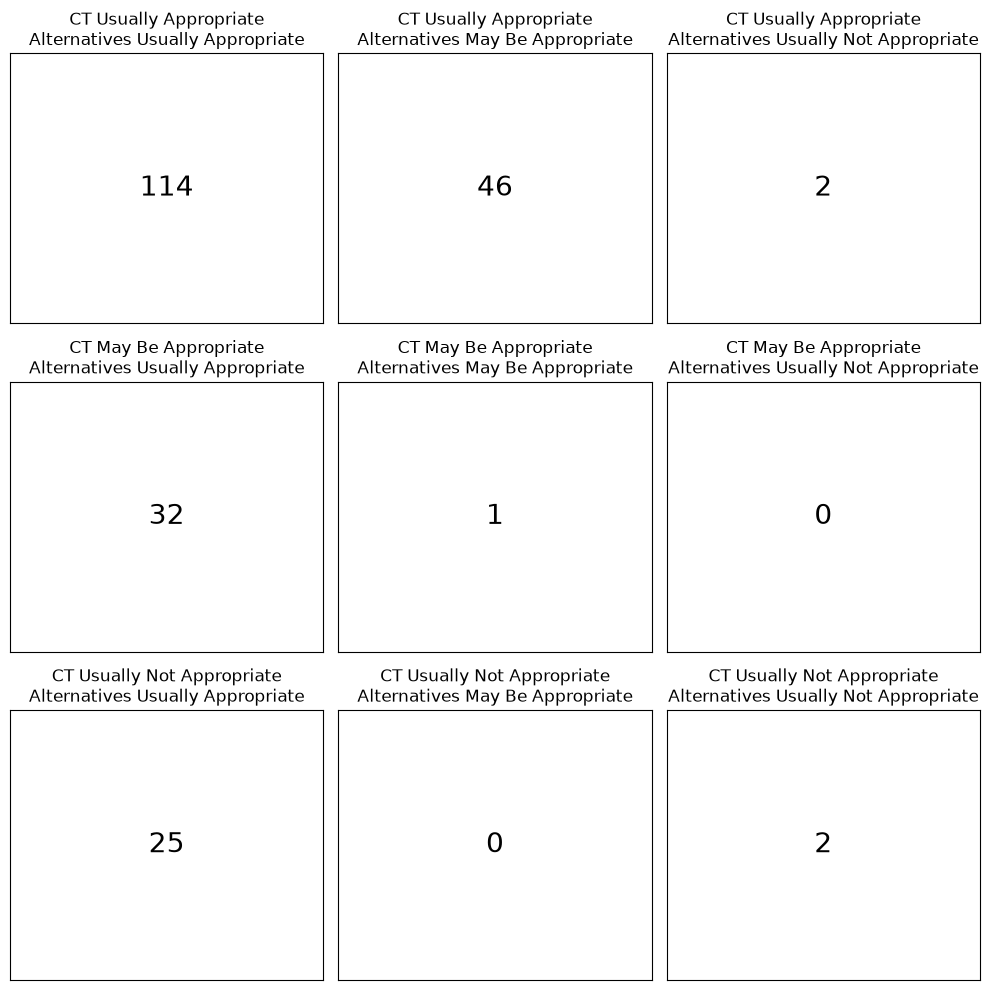

In [15]:
import matplotlib.pyplot as plt

def plot_category_grid(category_counts):
    # Create a 3x3 grid
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))

    # Row labels
    row_labels = ['CT Usually Appropriate', 'CT May Be Appropriate', 'CT Usually Not Appropriate']
    # Column labels
    col_labels = ['Alternatives Usually Appropriate', 'Alternatives May Be Appropriate', 'Alternatives Usually Not Appropriate']

    # Data for each cell
    data = [
        [category_counts['green-green'], category_counts['green-yellow'], category_counts['green-red']],
        [category_counts['yellow-green'], category_counts['yellow-yellow'], category_counts['yellow-red']],
        [category_counts['red-green'], category_counts['red-yellow'], category_counts['red-red']]
    ]

    # Plot each cell
    for i in range(3):
        for j in range(3):
            ax = axes[i, j]
            ax.text(0.5, 0.5, str(data[i][j]), fontsize=20, ha='center', va='center')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f'{row_labels[i]}\n{col_labels[j]}', fontsize=12)

    plt.tight_layout()
    plt.show()

plot_category_grid(category_counts(filtered_scenarios))

### Third level analysis - Specific alternative modalities to CT

Within each of the three classifications where an alternative is usually appropriate (CT is usually, may be, or usually not appropriate) what are the relative frequencies of MR vs. US vs. other modalities (plain radiography, flouroscopy, etc.)?

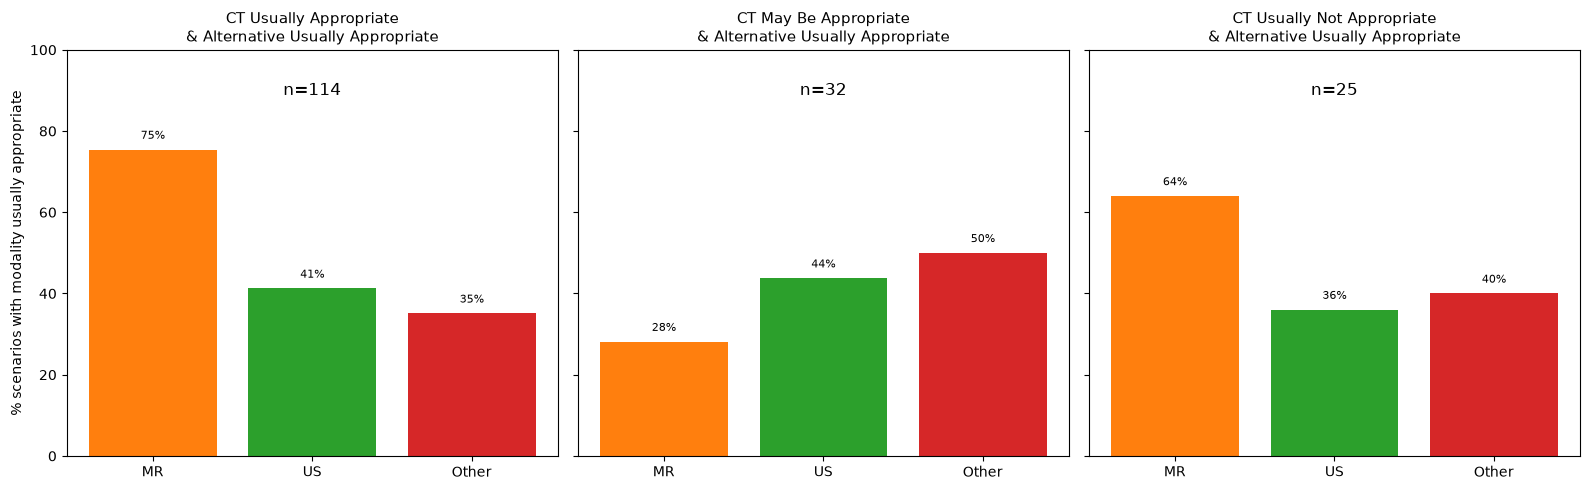

In [16]:
def plot_modality_percentages(data):
    modality_cols = ['mr_usually_appropriate', 'us_usually_appropriate', 'other_modality_usually_appropriate']
    modality_labels = ['MR', 'US', 'Other']
    colors = ['#ff7f0e', '#2ca02c', '#d62728']

    category_cols = ['green-green', 'yellow-green', 'red-green']
    titles = [
        'CT Usually Appropriate\n& Alternative Usually Appropriate',
        'CT May Be Appropriate\n& Alternative Usually Appropriate',
        'CT Usually Not Appropriate\n& Alternative Usually Appropriate'
    ]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

    for j, col in enumerate(category_cols):
        subset = data[data[col] == True]
        total_count = len(subset)
        percentages = subset[modality_cols].mean().mul(100) if total_count > 0 else pd.Series([0, 0, 0], index=modality_cols)

        ax = axes[j]
        ax.bar(modality_labels, percentages, color=colors)
        ax.set_title(titles[j], fontsize=11)
        ax.text(0.5, 0.92, f'n={total_count}', transform=ax.transAxes, ha='center', va='top', fontsize=12)
        ax.set_ylim(0, 100)
        if j == 0:
            ax.set_ylabel('% scenarios with modality usually appropriate')
        ax.set_xticks(range(len(modality_labels)))
        ax.set_xticklabels(modality_labels, rotation=0)

        for k, val in enumerate(percentages):
            ax.text(k, val + 2, f'{val:.0f}%', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

plot_modality_percentages(filtered_scenarios)


## Output Tables<a id='table_output'></a>

Place a list of scenarios for each of the 9 categories into an excel file.

![analysis grid](supplemental/analysis_grid.png)


In [17]:
from openpyxl.drawing.image import Image as XLImage

with pd.ExcelWriter('filtered_scenarios.xlsx', engine='openpyxl') as writer:
    pd.DataFrame().to_excel(writer, sheet_name='color codes', index=False)
    worksheet = writer.sheets['color codes']
    worksheet.add_image(XLImage('supplemental/analysis_grid.png'), 'A1')

    filtered_scenarios.to_excel(writer, sheet_name='all_scenarios', index=False)
    for col in category_cols:
        filtered_scenarios[filtered_scenarios[col]].to_excel(writer, sheet_name=col, index=False)


## Sub-analysis: 'Initial' imaging only

Limit the analyzed scenarios to just those that are indicated for initial imaging studies only, since these may be more common in the emergency department.

In [18]:
# limit filtered scenarios to just those that contain "initial" in the scenario-text (i.e. initial exams only)
initial_count = len(filtered_scenarios)
initial_scenarios = filtered_scenarios[filtered_scenarios['scenario-text'].str.contains('initial', case=False, na=False)]
print(f"Scenarios with 'initial' in text: {len(initial_scenarios)}")
print(f"Scenarios filtered out: {initial_count - len(initial_scenarios)}")

Scenarios with 'initial' in text: 132
Scenarios filtered out: 91


### Descriptive statistics (Initial imaging only)

How often is CT usually appropriate for ED abdominal complaints?

In [19]:
ct_usually_appropriate(initial_scenarios)

Number of scenarios where a CT study is usually appropriate: 91
Percentage of scenarios where a CT study is usually appropriate: 68.94%


How often is CT the ONLY usually appropriate study?

In [20]:
ct_only_usually_appropriate(initial_scenarios)

Number of cases where only CT is usually appropriate: 30
Percentage of cases where only CT is usually appropriate: 22.7%


,scenario-text
246,"Abd pain, acute, nonlocalized, fever, initial exam"
247,"Abd pain, acute, nonlocalized, fever, post op, initial exam"
249,"Abd pain, acute, nonlocalized, neutropenic, initial exam"
281,"Diaphragmatic hernia suspected, Bochdalek, initial imaging"
282,"Diaphragmatic hernia suspected, Morgagni, initial imaging"
283,"Diaphragmatic hernia suspected, traumatic, initial imaging"
326,"LLQ pain, diverticulitis complications suspected, initial imaging"
327,"LLQ pain, diverticulitis suspected, initial imaging"
328,"LLQ pain, initial imaging"
329,"Mesenteric ischemia, acute, suspected, initial exam"


How often is CT 'usually appropriate' or 'may be appropriate?

In [21]:
ct_usually_or_may_be_appropriate(initial_scenarios)

Percentage of cases where CT is 'usually' or 'may be' appropriate: 87.1% (n=115)


When is it NOT appropriate to use a CT study?

In [22]:
ct_not_appropriate(initial_scenarios)

Percentage of cases where CT is only not appropriate: 12.9% (n=17)



295                                                                Epigastric pain, hiatal hernia suspected, initial imaging
450                                                                                 Endometriosis suspected, initial imaging
451                                                                   Endometriosis suspected, rectosigmoid, initial imaging
465                                                                                      Fibroids suspected, initial imaging
468                                                                            Fibroids, treatment planning, initial imaging
517      Pelvic floor surgery, postoperative, chronic complications, not recurrent pelvic floor dysfunction, initial imaging
518     Pelvic floor surgery, postoperative, subacute complications, not recurrent pelvic floor dysfunction, initial imaging
519                                                                         Pelvic organ prolapse suspected, initial imaging


When is no imaging at all recommended?

In [23]:
no_studies_recommended(initial_scenarios)

Percentage of cases where no studies are recommended: 0.8% (n=1)



3106    Pyelonephritis suspected, acute, uncomplicated, first time presentation, initial imaging
Name: scenario-text, dtype: str

### CT vs. all other modalities (Initial imaging only)

In [24]:
print("Number of scenarios in each category for initial exams only:")
print(category_counts(initial_scenarios))
print(f"Total number of scenarios classified for initial exams only: {category_counts(initial_scenarios).sum()}")

Number of scenarios in each category for initial exams only:
green-green      61
green-yellow     30
green-red         0
yellow-green     24
yellow-yellow     0
yellow-red        0
red-green        16
red-yellow        0
red-red           1
dtype: int64
Total number of scenarios classified for initial exams only: 132


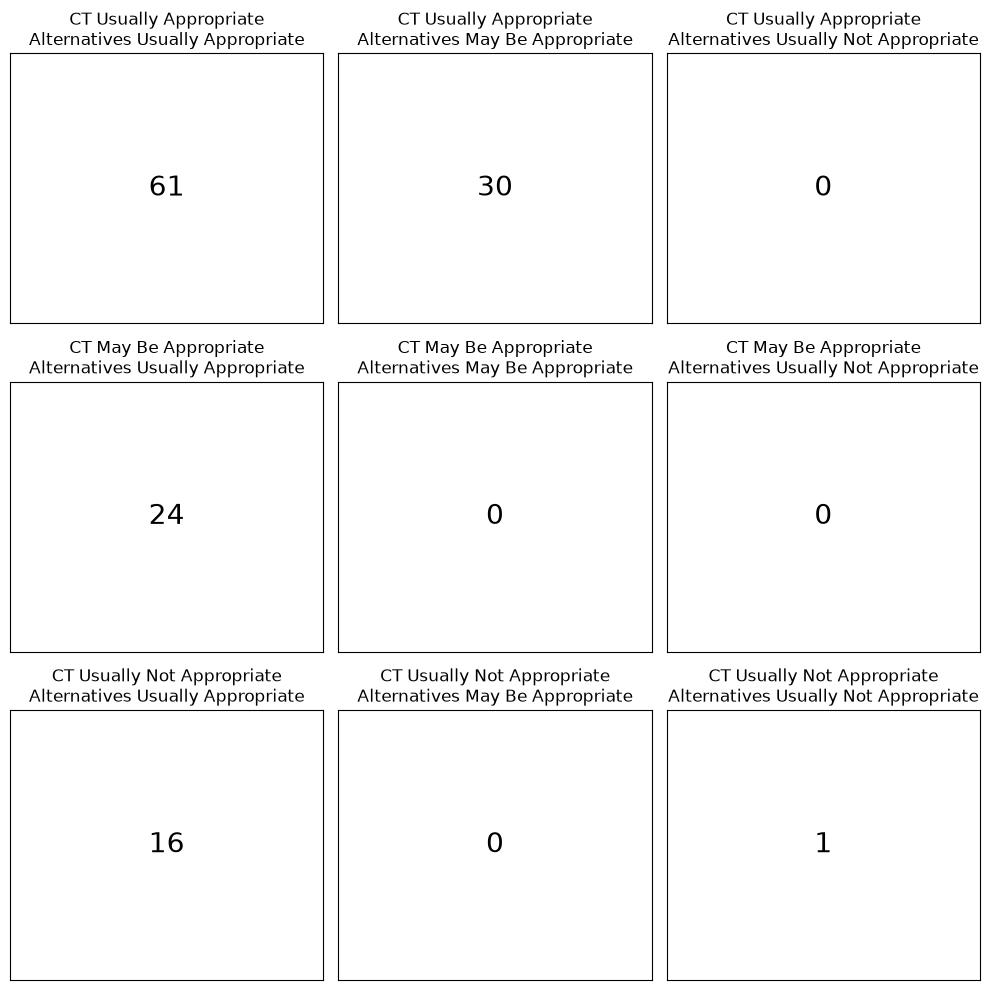

In [25]:
plot_category_grid(category_counts(initial_scenarios))

### Specific alternative modalities (Initial imaging only)

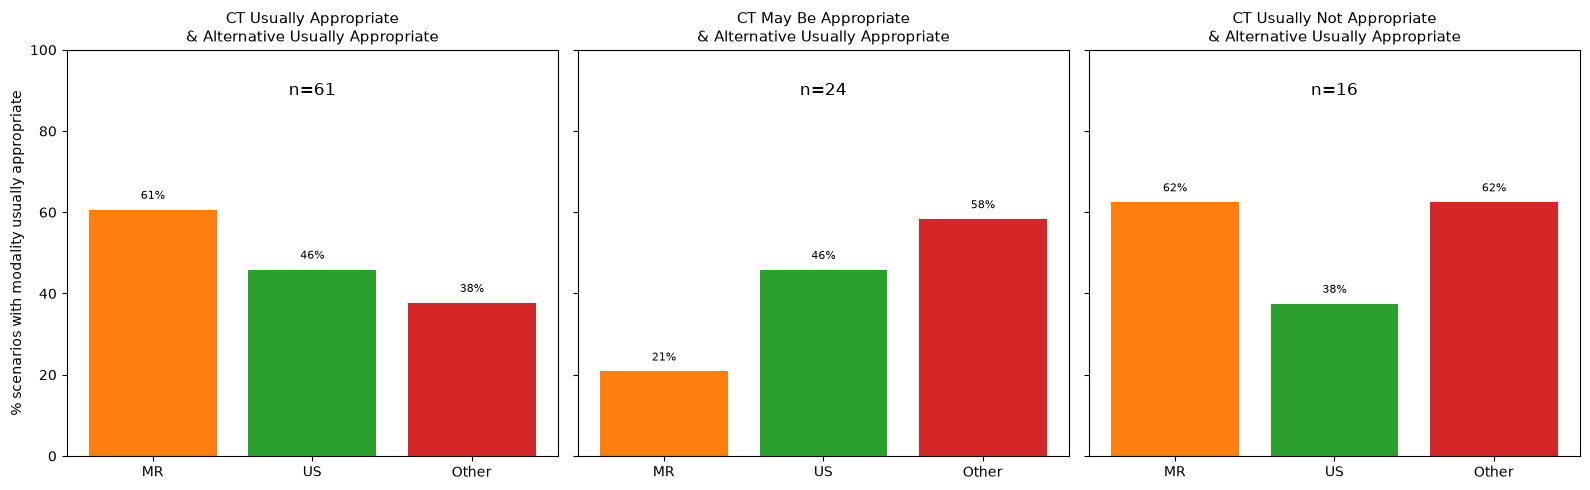

In [26]:
plot_modality_percentages(initial_scenarios)